In [21]:
import os
from pathlib import Path
from dotenv import load_dotenv

In [22]:
from cf_bench.config import SystemConfig
config = SystemConfig(backend="sklearn")
print(config)

=== System Config ===
backend                : sklearn
model_type             : classifier
target                 : hltprhc
feature_cols           : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']
ordinal_features       : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'dosprt']
continuous_features    : ['bmi']
ordinal_allowed_values : {'etfruit': [1, 2, 3, 4, 5, 6, 7], 'eatveg': [1, 2, 3, 4, 5, 6, 7], 'cgtsmok': [1, 2, 3, 4, 5, 6], 'alcfreq': [1, 2, 3, 4, 5, 6, 7], 'slprl': [1, 2, 3, 4], 'paccnois': [0, 1], 'dosprt': [0, 1, 2, 3, 4, 5, 6, 7]}
target_factor          : 0.5
features_to_vary       : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']


# Loading Data

The distibution of train / test == 80 / 20.

We have three target on the same dataset:
- "hltprhb",
- "hltprhc",

In previous steps the distribution of all target classes has been stratifed
into the train / test .csv-files.

We will train a RandomforestClassifier for each target.
They are regarded as Outcome variables, and are not to be used as features when not targets, but are dropped in training.


In [23]:
load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR"))
MODELS_DIR = Path(os.getenv("MODELS_DIR"))
TRAINING_PATH = DATA_DIR / "eta.csv"
TEST_PATH = DATA_DIR / "ete.csv"

print(DATA_DIR)
print(TRAINING_PATH)
print(TEST_PATH)

print(DATA_DIR.is_dir())
print(MODELS_DIR.is_dir())

print(TRAINING_PATH.is_file())
print(TEST_PATH.is_file())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/eta.csv
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/ete.csv
True
True
True
True


In [24]:
import pandas as pd

train_df = pd.read_csv(TRAINING_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [25]:
train_df

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,dosprt,hltprhc
0,3,3,6,5,1,0,21.453287,2,0
1,6,3,2,2,4,0,25.181077,7,0
2,4,1,3,2,2,0,23.529412,5,0
3,5,4,4,2,3,0,30.487805,2,0
4,4,4,2,2,2,0,26.769780,2,0
...,...,...,...,...,...,...,...,...,...
32878,4,4,6,6,1,0,22.679952,0,0
32879,1,2,4,7,1,0,23.875115,5,0
32880,2,2,6,2,1,0,23.629490,4,1
32881,4,4,6,7,2,0,29.700413,0,0


The distribution on the classes for all three targets are as we can see very skewed.
below we can se that the distribution is the same on train and test data-files.

In [26]:
TARGET = config.target

In [27]:
import matplotlib.pyplot as plt

def plot_target_distribution(train_df, test_df, target_col, label):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Train
    train_df[target_col].value_counts().plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"Train data-set")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha="right")

    # Test
    test_df[target_col].value_counts().plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Test data-set")
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Count")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="right")

    fig.suptitle(f"Distribution of {label} ({target_col})", fontsize=14)
    plt.tight_layout()
    plt.show()


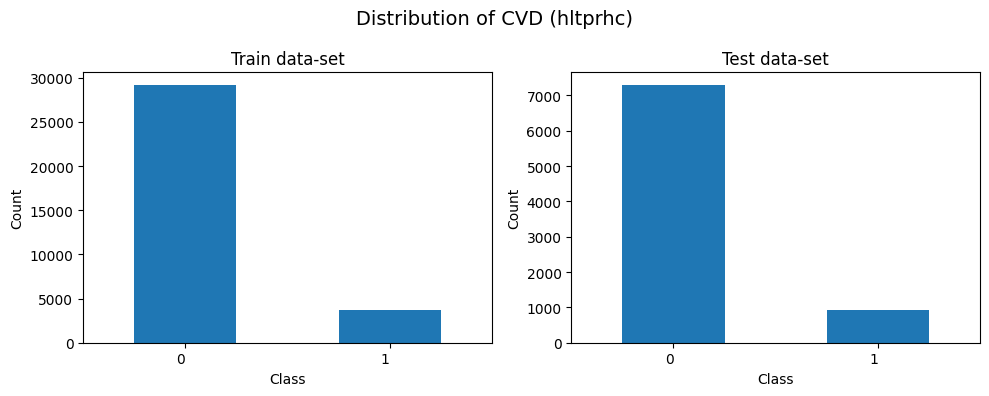

In [28]:
plot_target_distribution(train_df, test_df, TARGET, label="CVD")

In [29]:
# -------------------------
X = config.feature_cols
# -------------------------

y_train = train_df[TARGET]
X_train = train_df[X]

y_true = test_df[TARGET]
X_test = test_df[X]

# testing gridsearch on ESS-data, CVD (hltprhc) as target - XGBoost

In [ ]:
from scipy.stats import randint, uniform

# with 400 iterations

param_dist = {
    "xgb__n_estimators": randint(200, 1200),
    # More boosting rounds. Needed if learning_rate is small.

    "xgb__max_depth": randint(3, 15),
    # Allow deeper trees. Can capture more complex interactions.

    "xgb__learning_rate": uniform(0.005, 0.3),
    # Wider range. Very small LR + many trees can improve recall.

    "xgb__subsample": uniform(0.3, 0.7),
    # Allow more randomness. Helps generalization.

    "xgb__colsample_bytree": uniform(0.3, 0.7),
    # Same here. Lower values often help with noisy tabular data.

    "xgb__min_child_weight": randint(1, 15),
    # Larger range. Higher values prevent overfitting.

    "xgb__gamma": uniform(0, 5),
    # Much wider. Stronger split regularization can help stability.

    "xgb__scale_pos_weight": [1, 5, 10, 15, 20, 30, 40, 50],
    # Wider range for imbalanced data. Often the most important parameter.

    "xgb__reg_lambda": uniform(0, 10),
    # Stronger L2 regularization. Helps noisy datasets.

    "xgb__reg_alpha": uniform(0, 10),
    # Stronger L1 regularization. Can simplify trees.
}

In [44]:
# with 300 iterations

param_dist_refined = {
    "xgb__n_estimators": randint(300, 1000),
    # Focus on the range where good models appeared.

    "xgb__max_depth": randint(3, 10),
    # Best-performing models were between 3 and 8.

    "xgb__learning_rate": uniform(0.005, 0.145),
    # Narrowed around the successful region (0.01–0.15).

    "xgb__subsample": uniform(0.5, 0.5),
    # Good models used 0.55–0.95. Now searching 0.5–1.0.

    "xgb__colsample_bytree": uniform(0.5, 0.5),
    # Same here. Narrowed to 0.5–1.0.

    "xgb__min_child_weight": randint(1, 10),
    # Good models used 1–8. Slightly widened to 1–10.

    "xgb__gamma": uniform(0, 3),
    # Most good models had gamma between 0.1 and 3.

    "xgb__scale_pos_weight": [5, 10, 15, 20, 25],
    # Best-performing values were 10–20.

    "xgb__reg_lambda": uniform(0, 5),
    # Good models used 0.4–4.7.

    "xgb__reg_alpha": uniform(0, 5),
    # Same here. Narrowed to 0–5.
}

In [45]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

pipeline = Pipeline(
    [
        ("xgb", XGBClassifier(random_state=42, eval_metric="logloss"))
    ]
)

rand = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist_refined,
    n_iter=300,
    scoring="recall_macro",
    n_jobs=-1,
    cv=5,
    verbose=2,
    random_state=42,
)

rand.fit(X_train, y_train)

print("RandomizedSearch Done. best score (cv):", rand.best_score_)
print("Best parameters:")
print(rand.best_params_)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
[CV] END xgb__colsample_bytree=0.6872700594236812, xgb__gamma=2.8521429192297485, xgb__learning_rate=0.11113912156265374, xgb__max_depth=7, xgb__min_child_weight=5, xgb__n_estimators=914, xgb__reg_alpha=2.229163764267956, xgb__reg_lambda=0.4998745790900144, xgb__scale_pos_weight=15, xgb__subsample=0.9330880728874675; total time=   1.6s
[CV] END xgb__colsample_bytree=0.6872700594236812, xgb__gamma=2.8521429192297485, xgb__learning_rate=0.11113912156265374, xgb__max_depth=7, xgb__min_child_weight=5, xgb__n_estimators=914, xgb__reg_alpha=2.229163764267956, xgb__reg_lambda=0.4998745790900144, xgb__scale_pos_weight=15, xgb__subsample=0.9330880728874675; total time=   1.7s
[CV] END xgb__colsample_bytree=0.6872700594236812, xgb__gamma=2.8521429192297485, xgb__learning_rate=0.11113912156265374, xgb__max_depth=7, xgb__min_child_weight=5, xgb__n_estimators=914, xgb__reg_alpha=2.229163764267956, xgb__reg_lambda=0.4998745790900144, xg

In [56]:
res = pd.DataFrame(rand.cv_results_)

top_estimators = (
    res
    .sort_values("mean_test_score", ascending=False)
    .head(20)
)

top_estimators = top_estimators.drop(columns=[c for c in top_estimators.columns if c.startswith("param_")])
params = top_estimators["params"].apply(pd.Series)

top_estimators = pd.concat([top_estimators.drop(columns=["params"]), params], axis=1)

top_estimators


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,...,xgb__colsample_bytree,xgb__gamma,xgb__learning_rate,xgb__max_depth,xgb__min_child_weight,xgb__n_estimators,xgb__reg_alpha,xgb__reg_lambda,xgb__scale_pos_weight,xgb__subsample
183,0.725765,0.039030,0.045314,0.003854,0.628182,0.638823,0.649689,0.637860,0.615134,0.633938,...,0.690455,1.038965,0.039663,3.0,3.0,479.0,1.398518,4.711935,10.0,0.757840
227,1.332586,0.076194,0.109611,0.016810,0.632914,0.640089,0.642134,0.637932,0.614428,0.633500,...,0.780611,1.570173,0.021641,4.0,9.0,722.0,3.539175,2.717691,10.0,0.742348
224,1.591889,0.083428,0.149073,0.003954,0.629693,0.640643,0.650168,0.634260,0.611649,0.633283,...,0.673672,2.699500,0.008164,5.0,4.0,771.0,2.800841,4.684112,10.0,0.913934
38,1.494143,0.061338,0.127337,0.024016,0.627685,0.638771,0.653015,0.628057,0.615270,0.632560,...,0.943340,0.782681,0.007219,5.0,1.0,624.0,3.419819,3.079256,10.0,0.513256
101,0.541966,0.015632,0.040993,0.004149,0.629982,0.638202,0.634962,0.641369,0.613484,0.631600,...,0.743716,2.683657,0.120979,3.0,2.0,414.0,2.562288,3.708435,10.0,0.816739
166,0.896724,0.035063,0.073841,0.007992,0.631505,0.639037,0.634579,0.636525,0.612520,0.630833,...,0.512821,1.023743,0.060128,4.0,5.0,599.0,2.383477,1.971827,10.0,0.857745
37,0.566996,0.058801,0.046460,0.010230,0.625581,0.634900,0.644961,0.634298,0.612192,0.630386,...,0.508581,2.290093,0.122002,6.0,1.0,553.0,2.169258,1.992524,10.0,0.974573
59,1.402721,0.088540,0.120919,0.008486,0.627608,0.638094,0.637326,0.638387,0.608795,0.630042,...,0.623674,1.351632,0.023728,5.0,4.0,745.0,4.391103,3.784996,10.0,0.679081
222,0.971949,0.021864,0.095865,0.003402,0.623454,0.636548,0.638646,0.637329,0.612158,0.629627,...,0.528527,0.846561,0.042947,5.0,7.0,519.0,3.935633,4.874173,10.0,0.922395
165,0.503363,0.033062,0.036692,0.002851,0.623387,0.641250,0.639468,0.633479,0.609087,0.629334,...,0.793531,0.505333,0.098174,4.0,9.0,302.0,2.711818,4.757393,10.0,0.739591


In [57]:
desired_order = [
    "mean_fit_time", "std_fit_time",
    "mean_score_time", "std_score_time",
    "split0_test_score", "split1_test_score", "split2_test_score",
    "split3_test_score", "split4_test_score",
    "mean_test_score", "std_test_score", "rank_test_score",
    "xgb__n_estimators",
    "xgb__max_depth",
    "xgb__learning_rate",
    "xgb__subsample",
    "xgb__colsample_bytree",
    "xgb__min_child_weight",
    "xgb__gamma",
    "xgb__scale_pos_weight",
]

top_estimators = top_estimators[desired_order]

### save to csv

In [58]:
def append_run(df_new:pd.DataFrame, csv_path):
    """
    Appends a new run to a CSV file, automatically generating an incrementing run_id.
    Ensures run_id is the first column.
    """
    df_new = df_new.copy()

    # Determine next run_id
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        next_id = df_existing["run_id"].max() + 1 if "run_id" in df_existing else 1
    else:
        next_id = 1

    # Assign run_id
    df_new["run_id"] = str(next_id).zfill(3)

    # round the decimals
    df_new = df_new.round(3)

    # Move run_id to the first column
    cols = ["run_id"] + [c for c in df_new.columns if c != "run_id"]
    df_new = df_new[cols]

    # Append or create file
    df_new.to_csv(
        csv_path,
        mode="a" if os.path.exists(csv_path) else "w",
        header=not os.path.exists(csv_path),
        index=False
    )


In [59]:
csv_grid_path = "xgb_gridsearch_runs.csv"

append_run(top_estimators, csv_grid_path)

### investigate run metrics

In [60]:
best_xgb = rand.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)

In [61]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_true, best_xgb_pred))
print()
print("ROC AUC score:", roc_auc_score(y_true, best_xgb_pred), "\n")

              precision    recall  f1-score   support

           0       0.94      0.54      0.68      7287
           1       0.17      0.74      0.27       934

    accuracy                           0.56      8221
   macro avg       0.55      0.64      0.48      8221
weighted avg       0.85      0.56      0.64      8221


ROC AUC score: 0.6360454171856895 



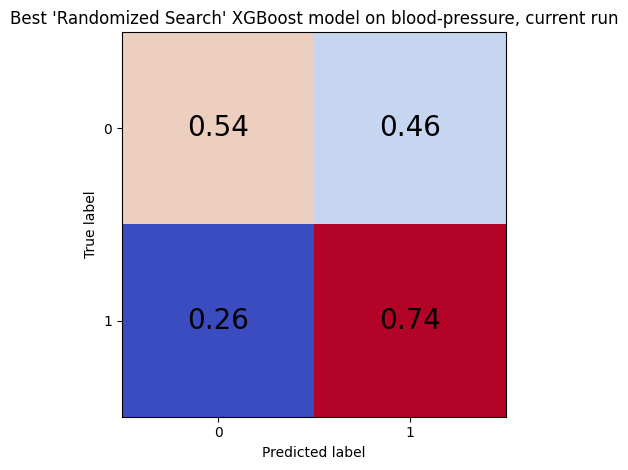

In [62]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    best_xgb_pred,
    colorbar=False,
    cmap="coolwarm",
    normalize="true"
)

for row in disp.text_:
    for t in row:
        t.set_fontsize("20")
        t.set_color("black")

plt.title("Best 'Randomized Search' XGBoost model on blood-pressure, current run")
plt.tight_layout()
plt.show()

# Analysis

When training machine‑learning classifiers on imbalanced datasets, it is common to observe a systematic shift in error patterns depending on the choice of class weighting. In the unweighted case, models tend to minimize overall error by favoring the majority class, which typically results in high false‑negative rates for the minority class. This occurs because misclassifying minority‑class samples has little impact on the loss function when the majority class dominates the data distribution.

For XGBoost, the `scale_pos_weight` parameter serves a similar function to class weights in Random Forest. It adjusts the balance between positive and negative classes by scaling the gradient for the positive class. A higher value increases the penalty for misclassifying minority samples, shifting the decision boundary toward greater sensitivity. As with Random Forest, this reduces false negatives but typically increases false positives.

XGBoost also offers other mechanisms for handling imbalanced data, such as adjusting the learning rate, tree depth, and regularization parameters (gamma, min_child_weight). These parameters control the model's complexity and can help prevent overfitting to the majority class while maintaining generalization performance.

In these experiments, if XGBoost performance plateaus across the hyperparameter search space, it suggests that the model has reached its limit under the current feature representation and data distribution. Further improvements may require feature engineering, threshold adjustment, probability calibration, or ensemble methods combining multiple model types.